In [26]:
from meteofetch import Arome0025

# Fetch latest forecast for Arome 0.025° model
datasets = Arome0025.get_latest_forecast(paquet="SP2")
# SP1, tp
# SP2  lcc, mcc, hcc

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [2]:
datasets.keys()

dict_keys(['d2m', 'sh2', 'mx2t', 'mn2t', 't', 'sp', 'blh', 'h', 'lcc', 'mcc', 'hcc', 'tirf', 'CAPE_INS'])

In [29]:
import xarray as xr

# Example: Load a dataset
da = datasets["lcc"]  # Temperature at 2 meters

# Check coordinates
print(da.coords)  # Shows latitude, longitude, time, etc.

# Check if the grid is regular
lat_diff = da.latitude.diff(dim="latitude").mean().values
lon_diff = da.longitude.diff(dim="longitude").mean().values
print(f"Average lat spacing: {lat_diff}, lon spacing: {lon_diff}")

Coordinates:
  * time         (time) datetime64[ns] 408B 2026-05-08T10:00:00 ... 2026-05-1...
    step         (time) timedelta64[ns] 408B 01:00:00 ... 2 days 03:00:00
  * latitude     (latitude) float64 6kB 37.5 37.53 37.55 ... 55.35 55.38 55.4
  * longitude    (longitude) float64 9kB -12.0 -11.97 -11.95 ... 15.98 16.0
    surface      float64 8B 0.0
    spatial_ref  int64 8B 0
Average lat spacing: 0.024999999999999998, lon spacing: 0.025


In [31]:
da_l = datasets["lcc"]  # Temperature at 2 meters
da_m = datasets["mcc"]  # Temperature at 2 meters
da_h = datasets["hcc"]  # Temperature at 2 meters


layer_l = da_l.isel(time=0)
layer_m = da_m.isel(time=0)
layer_h = da_h.isel(time=0)


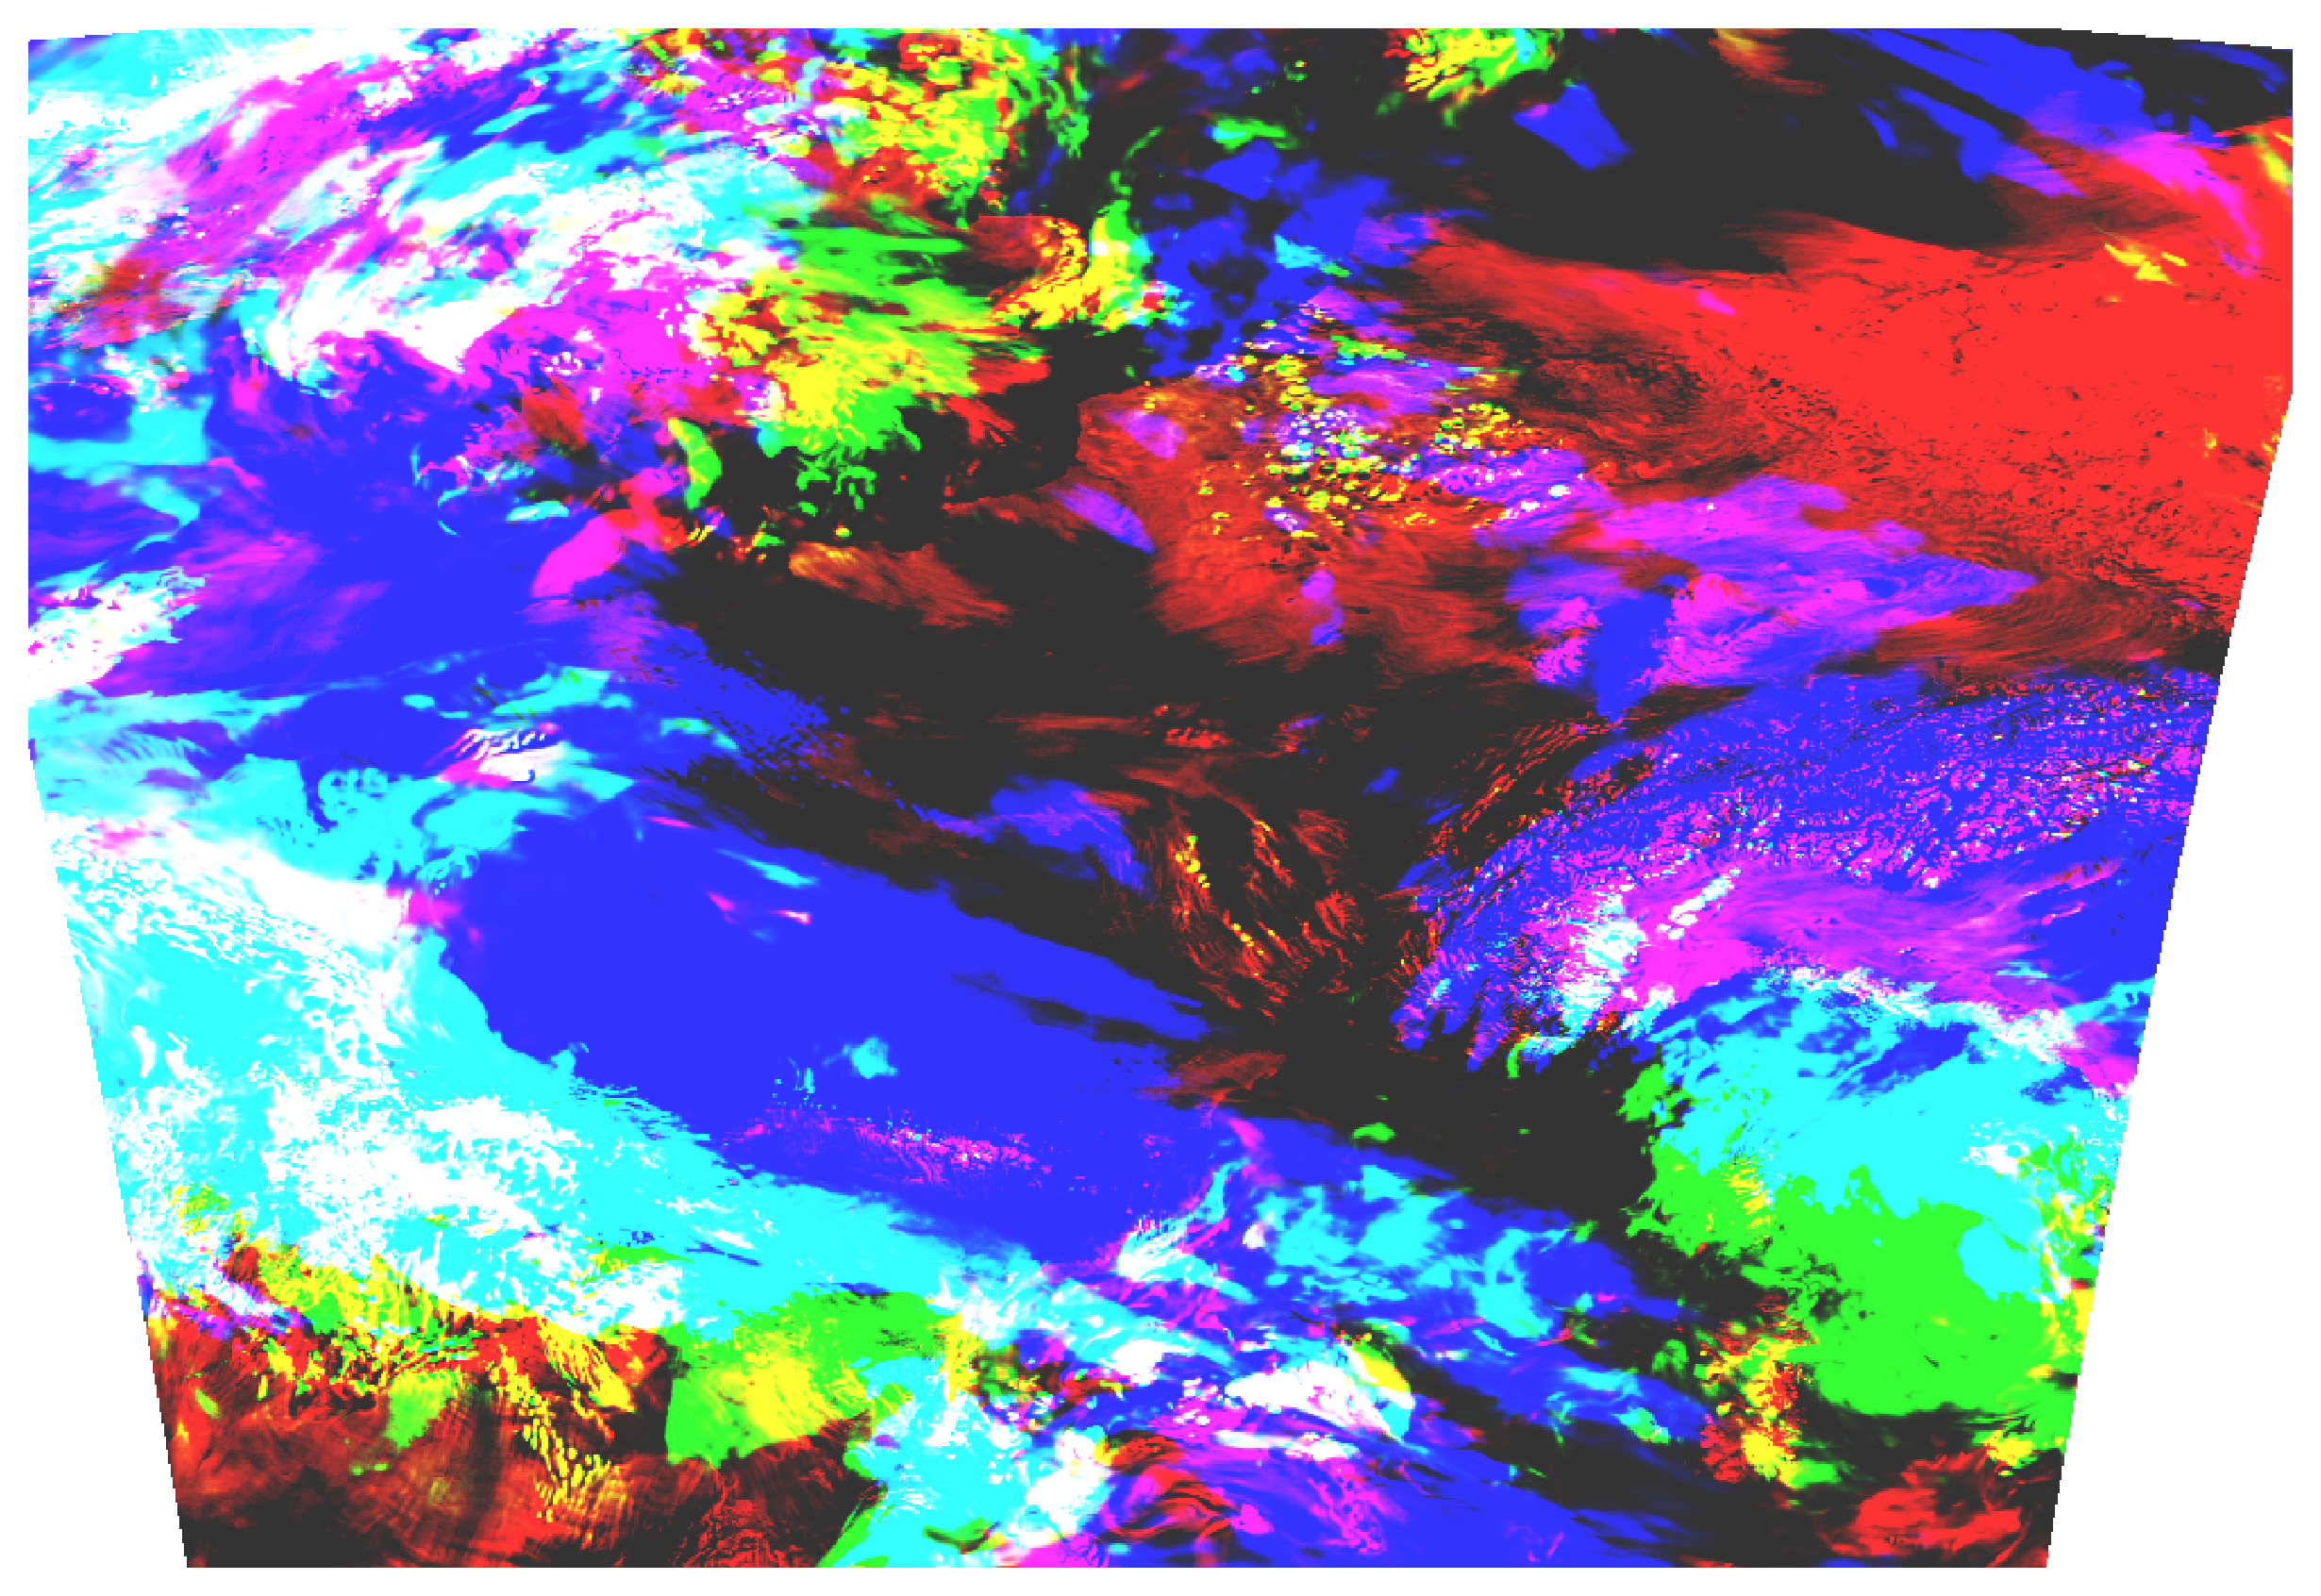

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from typing import List, Optional

def plot_three_layers_to_png(
    layers: List,
    output_path: Path = Path("./three_layers_plot.png"),
    dpi: int = 300,
    show: bool = False,
    alpha: float = 0.7,  # Transparency for non-zero values
):
    """
    Plot three 2D layers (latitude x longitude) as a combined PNG with primary colors (R, G, B) and transparency for 0 values.

    Args:
        layers: List of 3 xarray.DataArray objects (for R, G, B channels).
        output_path: Path to save the PNG. Default: "./three_layers_plot.png".
        dpi: DPI for the output image. Default: 300.
        show: If True, display the plot interactively. Default: False.
        alpha: Transparency for non-zero values (0-1). Default: 0.7.
    """
    if len(layers) != 3:
        raise ValueError("Exactly 3 layers (R, G, B) are required.")

    # Extract data and coordinates (assume all layers share the same grid)
    data_r = layers[0].values
    data_g = layers[1].values
    data_b = layers[2].values
    lons = layers[0].longitude.values
    lats = layers[0].latitude.values

    # Normalize each layer to [0, 1] for RGB mapping
    def normalize(data):
        data = np.clip(data, 0, None)  # Clip negative values to 0
        max_val = np.nanmax(data)
        if max_val == 0:
            return np.zeros_like(data)
        return data / max_val

    data_r_norm = normalize(data_r)
    data_g_norm = normalize(data_g)
    data_b_norm = normalize(data_b)

    # Create RGB array (shape: [lat, lon, 4] for RGBA)
    rgb = np.zeros((*data_r_norm.shape, 4))
    rgb[..., 0] = data_r_norm  # Red channel
    rgb[..., 1] = data_g_norm  # Green channel
    rgb[..., 2] = data_b_norm  # Blue channel
    rgb[..., 3] = np.where((data_r_norm > 0) | (data_g_norm > 0) | (data_b_norm > 0), alpha, 0)  # Alpha channel

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6), dpi=dpi)

    # Display the RGB image
    ax.imshow(
        rgb,
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        origin='lower',
        interpolation='nearest'
    )

    # Set the map extent: 10W to 15E, 38N to 55N
    ax.set_xlim(-10, 15)
    ax.set_ylim(38, 55)

    # Remove title, scale, and ticks
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove spines (frame borders)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Ensure only the frame (data) is exported
    plt.tight_layout(pad=0)

    # Save the plot
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(
        output_path,
        dpi=dpi,
        bbox_inches='tight',
        pad_inches=0,
        transparent=True
    )

    if show:
        plt.show()

    plt.close()

plot_three_layers_to_png(
    layers=[layer_l, layer_m, layer_h],
    output_path=Path("/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france//my_clouds.png"),
    dpi=300,
    alpha=0.8,
    show=True
)



